[Boostcource](https://www.boostcourse.org/) Statistics 110의 10강을 듣고 정리. Linearity, Putnam problem, Negative Binomial, St. Petersburg paradox에 대해 설명한다.

# Proof of linearlity
문제) 확률변수 $T$, $X$, $Y$가 있고, $T = X + Y$일때,  $E(T) = E(X) + E(Y)$를 보여라.  
즉, 기대값이 선형성을 만족하는지 증명

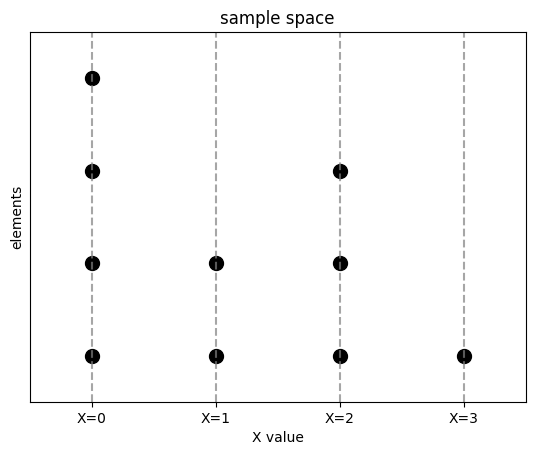

In [1]:
#| label: fig-sample-space
#| fig-cap: "Sample Space"
#| echo: false
import matplotlib.pyplot as plt

# 샘플 공간의 각 X 값과 그에 해당하는 원소들의 y 좌표
x_values = [0, 1, 2, 3]
y_values = [
    [0, 1, 2, 3],  # X=0에 해당하는 원소들
    [0, 1],  # X=1에 해당하는 원소들
    [0, 1, 2],  # X=2에 해당하는 원소들
    [0]  # X=3에 해당하는 원소들
]

# 플롯 설정
fig, ax = plt.subplots()

# 각 X 값에 대해 그룹화된 점을 그림
for x, ys in zip(x_values, y_values):
    ax.scatter([x] * len(ys), ys, s=100, color='black')  # 동일한 x값에 여러 y값

# 축과 텍스트 추가
ax.set_xticks(x_values)
ax.set_xticklabels([f'X={x}' for x in x_values])
ax.set_yticks([])
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel("X value")
ax.set_ylabel("elements")
ax.set_title("sample space")

# 그리드와 박스
for x in x_values:
    ax.axvline(x, color='gray', linestyle='--', alpha=0.7)  # 수직 선

plt.show()

강의에선 표본 공간의 event를 조약돌로 비유한다. 각각의 조약돌은 어떤 확률로 특정 값에 매핑된다. 조약돌 표본 공간을 Discrete RV 그림으로 나타내면 위와 같다. 4개의 조약돌이 $X=0$로 매핑, 2개의 조약돌이 $X=1$로 매핑, 3개의 조약돌이 $X=2$로 매핑, 1개의 조약돌이 $X=3$으로 매핑된다. 위의 표본 공간에서 평균을 구하는 방법은 두 가지가 있다.

- 각 확률변수 X마다 grouping을 해서 비율과 값을 곱해서 더한다. 즉, 가중평균을 구한다.
- 값이 발생한 수(event, 조약돌의 값)를 다 더해서 전체 갯수로 나눈다.

이 두 가지 방법을 식으로 나타내면 다음과 같다.

$$
E(X) = \sum_x xP(X=x) = \sum_s X(s) P(\{s\}) \quad(\text{$P(\{s\})$ is mass of pebbles})
$$

위 식의 $X(s)$ : X는 확률변수 = 어떤 값으로 매핑하는 함수이고 어떤 조약돌 s를 어떤 값에 매핑한다. $P(\{s\})$는 조약돌의 질량. 여기서 각 조약돌은 1의 질량을 가진다. 각각의 방법으로 기대값을 구하는 과정은 다음과 같다.

- 첫 번째 방법 : $0 \cdot 4/10 + 1 \cdot 2/10 + 2 \cdot 3/10 + 3 \cdot 10$
- 두 번째 방법 : $(0+0+0+0+1+1+2+2+2+3)/10$

두 번째 방법을 사용하면 기대값의 선형성을 쉽게 증명할 수 있다.

$$
\begin{align}
E(T) & = \sum_s(X+Y)(s) \cdot P(\{s\}) = \sum_s(X(s)+Y(s)) \cdot P(\{s\}) \\
& = \sum_sX(s)\cdot P(\{s\}) \; + \sum_sY(s)\cdot P(\{s\}) \\
& = E(X) + E(Y)
\end{align}
$$

같은방법으로 $E(cX) = cE(X)$도 증명할 수 있다.

# Negative Binomial Distribution
음이항분포는 기하분포의 일반화된 형태이다. 음이항분포는 i.i.d $Bern(p)$ trials의 sequence에서 r번째 성공까지 발생하는 실패 횟수를 나타내는 확률분포이다. 예를들어 `1001001001` sequence에서 $r=4$, 실패횟수 $n=6$이다. PMF $P(X=n)$은 $n$번 실패할 확률이다. PMF 식을 구하려면, $r-1$번 성공과 $n$번 실패의 combination + 마지막 $r$번째 성공으로 구할 수 있다.

$$
P(X=n) = \binom{n+r-1}{r-1} \cdot p^r \cdot (1-p)^n
$$

PMF로 기대값 $E(X)$를 구하는 것은 어렵지만, 문제를 분해하면 간단해진다.

1. $X_j$를 j-1번째 성공과 j번째 성공 사이의 실패 횟수로 정의
2. 각 $X_j$는 기하분포를 따름

$$
\begin{align}
E(X) & = E(X_1 + X_2+ \cdots + X_r) = E(X_1) + E(X_2) + \cdots + E(X_r) \\
& = r \cdot q/p
\end{align}
$$

# First Success distribution
First Success distribution은 첫 번째 성공이 나올 때까지의 시행 횟수(성공 포함)를 나타낸다. 이를 확률 변수 $X$로 정의하면, $X \sim FS(p)$이며  $p$는 성공 확률이다. $X$는 성공을 포함한 시도 횟수를 나타내므로, $X$를 기하 분포 $Y \sim Geom(p)$, $X = Y+1$로 표현할 수 있다. 기하 분포 $Y \sim Geom(p)$은 성공을 제외한 실패 횟수를 나타내고, $X$를 $Y$에 성공 시도를 더한 것으로 표현한다.

$E(Y)=(1-p)/p$이고, 선형성을 이용하면

$$
E(X) = E(Y) + 1 = (1-p)/p + 1 = 1/p
$$

이는 성공할 확률이 $1/10$이라면, 평균적으로 10번 시도하면 성공한다

> Gemetric Distribution은 책마다 정의가 다르다. (성공을 포함하는 지, 안하는 지)

# 2006년 Putnam Competition A4 문제
Putnam 경시대회는 매우 어려운 수학시험이고, 대부분 0점이라고 한다.  
1~n개 숫자의 무작위 순열에서 local maxima의 개수에 대한 기댓값을 구하는 문제.  
(3) 2 1 4 (7) 5 (6) - 주변보다 큰 수를 local maxima라 하고 여기서 3, 7, 6으로 3개이다.

1. indicator RV $I_j$ 를 사용, $j$ 위치가 local maxima이면 $I_j=1$, 아니면 $I_j=0$
2. $I_1+\cdots+I_n$이 local maxima의 개수, $E(I_1+\cdots+I_n)$를 구하는 것이 목표
3. 중간의 3개의 수 "4 7 5"에서 local maxima가 존재할 확률 = $1/3$, $n-2$개 존재
4. 끝 위치의 수 "3 2"에서 local maxima가 존재할 확률 = $1/2$, $2$개 존재

선형성을 이용하면,

$$
E(I_1+\cdots+I_n) = E(I_1)+\cdots+E(I_n) = \frac{n-2}{3} + \frac{2}{2} = \frac{n+1}{3}
$$

indicator RV의 기댓값은 사건의 확률과 같다.

# 상트페테르부르크 역설(St. Petersburg Paradox)

첫 앞면이 나올 때까지의 동전 던지기 횟수를 $x$라 할 때, $2^x$ 달러를 받는 게임의 기댓값 구하기.

$$
E(Y) = \sum_{k=1}^{\infty}2^k \cdot \frac{1}{2^k} = \infty
$$

이론적으로는 무한한 기대값을 가지지만, 현실적인 제약으로 1조 달러($2^{40}$) 상한이 있다면, $E(Y) = \sum_{k=1}^{40} 1 = 40$처럼 유한한 값을 가진다.

# 참고
[https://en.wikipedia.org/wiki/Event_(probability_theory)](https://en.wikipedia.org/wiki/Event_(probability_theory))
[https://en.wikipedia.org/wiki/Negative_binomial_distribution](https://en.wikipedia.org/wiki/Negative_binomial_distribution)
[https://en.wikipedia.org/wiki/Geometric_distribution](https://en.wikipedia.org/wiki/Geometric_distribution)
[https://en.wikipedia.org/wiki/St._Petersburg_paradox](https://en.wikipedia.org/wiki/St._Petersburg_paradox)